In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from operator import attrgetter


In [5]:
# Load data
orders = pd.read_csv('Downloads/MohammadSaizeAli_customer_orders.csv', parse_dates=['order_date'])

In [7]:
# Cohort analysis
orders['cohort_month'] = orders.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
orders['order_month'] = orders['order_date'].dt.to_period('M')
orders['cohort_index'] = (orders['order_month'] - orders['cohort_month']).apply(attrgetter('n'))

In [9]:
# Calculate retention
cohort_data = orders.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0)

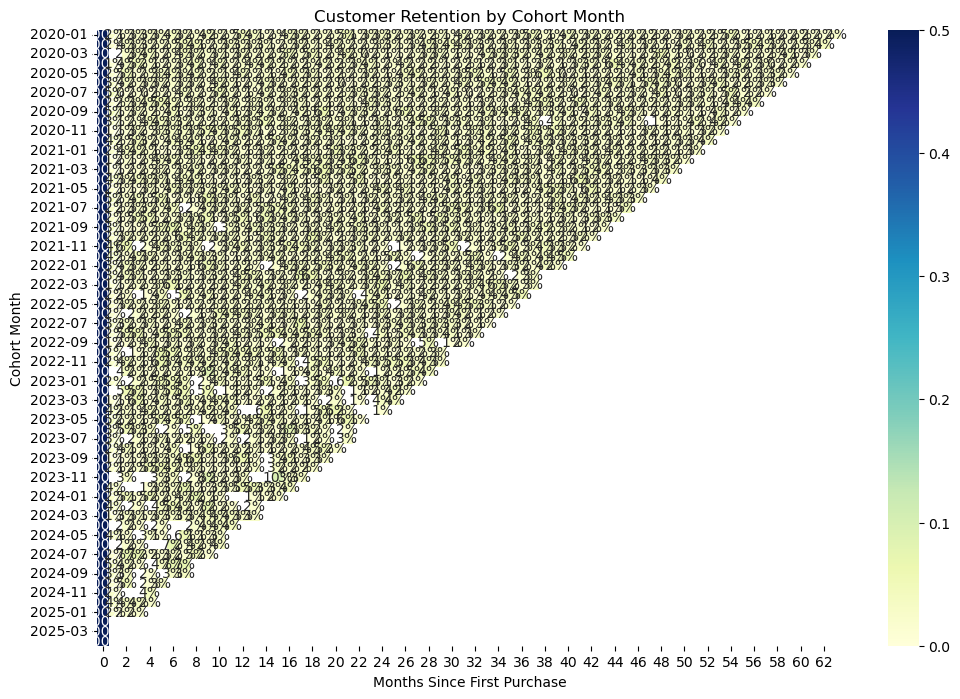

In [11]:
# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0, vmax=0.5)
plt.title('Customer Retention by Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.savefig('retention_heatmap.png')
plt.show()